In [150]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from scipy.stats import norm
import itertools

# Sentiment classification



In [151]:
def plot_sensitivity_hists(preds, Y_te, title):
    preds_neg = preds[Y_te == "neg"][:,1]
    preds_pos = preds[Y_te == "pos"][:,1]
    plt.figure()
    plt.hist(preds_neg, bins=20, density=True, alpha=0.5, label="neg")
    plt.hist(preds_pos, bins=20, density=True, alpha=0.5, label="pos")
    plt.xlabel("Probability")
    plt.ylabel("Density")
    plt.title(title)
    plt.legend()

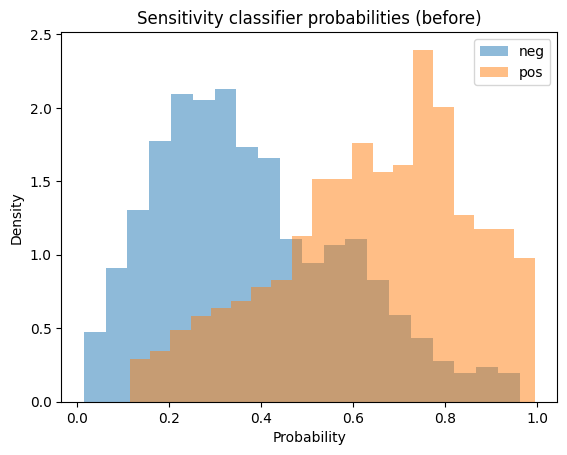

In [152]:
X = np.load("embedding_orig.npy")
Y = np.load("labels.npy", allow_pickle=True)[:, 1]

X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2)

logreg = LogisticRegression()
logreg.fit(X_tr, Y_tr)
preds = logreg.predict_proba(X_te)

plot_sensitivity_hists(preds, Y_te, "Sensitivity classifier probabilities (before)")
plt.savefig("sentiment_before.png")
plt.show()

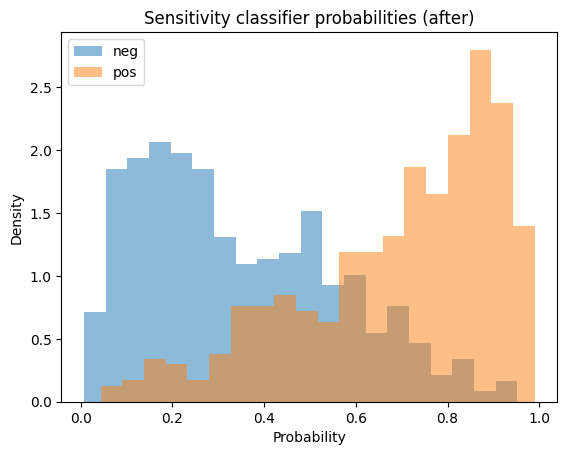

In [153]:
X = np.load("embedding_dist.npy")
Y = np.load("labels.npy", allow_pickle=True)[:, 1]

X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2)

logreg = LogisticRegression()
logreg.fit(X_tr, Y_tr)
preds = logreg.predict_proba(X_te)

plot_sensitivity_hists(preds, Y_te, "Sensitivity classifier probabilities (after)")
plt.savefig("sentiment_after.png")
plt.show()

# Topic classification

In [154]:
def plot_topic_hists(preds, Y_te, title):
    topics = ["books", "dvd", "music", "health", "software", "camera"]
    rows=3
    cols=2
    fig, axs = plt.subplots(rows, cols, figsize=(cols*7, rows*5))
    fig.suptitle(title)
    for row, col in itertools.product(range(rows), range(cols)):
        i = row*cols + col
        topic = topics[i]
        preds_topic = preds[Y_te == topic][:,i]
        preds_other = preds[Y_te != topic][:,i]
        ax = axs[row,col]
        ax.hist(preds_topic, bins=20, density=True, alpha=0.5, label=topic)
        ax.hist(preds_other, bins=20, density=True, alpha=0.5, label="other")
        ax.set_xlabel("Probability")
        ax.set_ylabel("Density")
        ax.set_title(f"Probability distribution for \"{topic}\"")

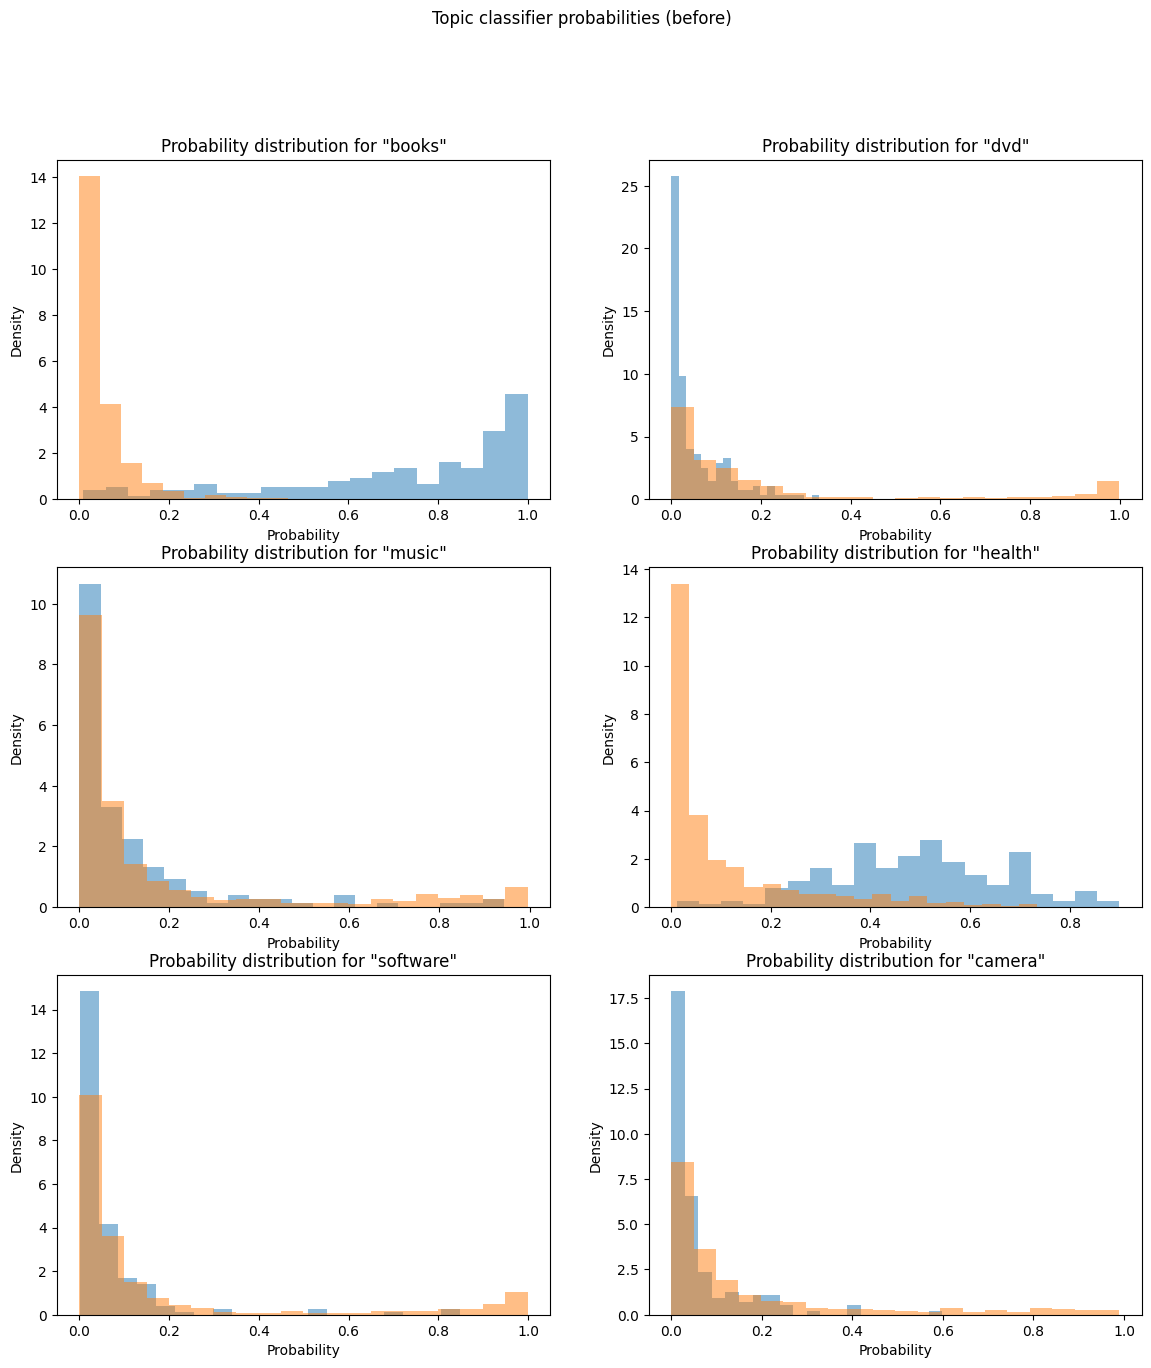

In [155]:
X = np.load("embedding_orig.npy")
Y = np.load("labels.npy", allow_pickle=True)[:, 0]

X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2)

logreg = LogisticRegression()
logreg.fit(X_tr, Y_tr)
preds = logreg.predict_proba(X_te)

plot_topic_hists(preds, Y_te, "Topic classifier probabilities (before)")
plt.savefig("topic_before.png")
plt.show()

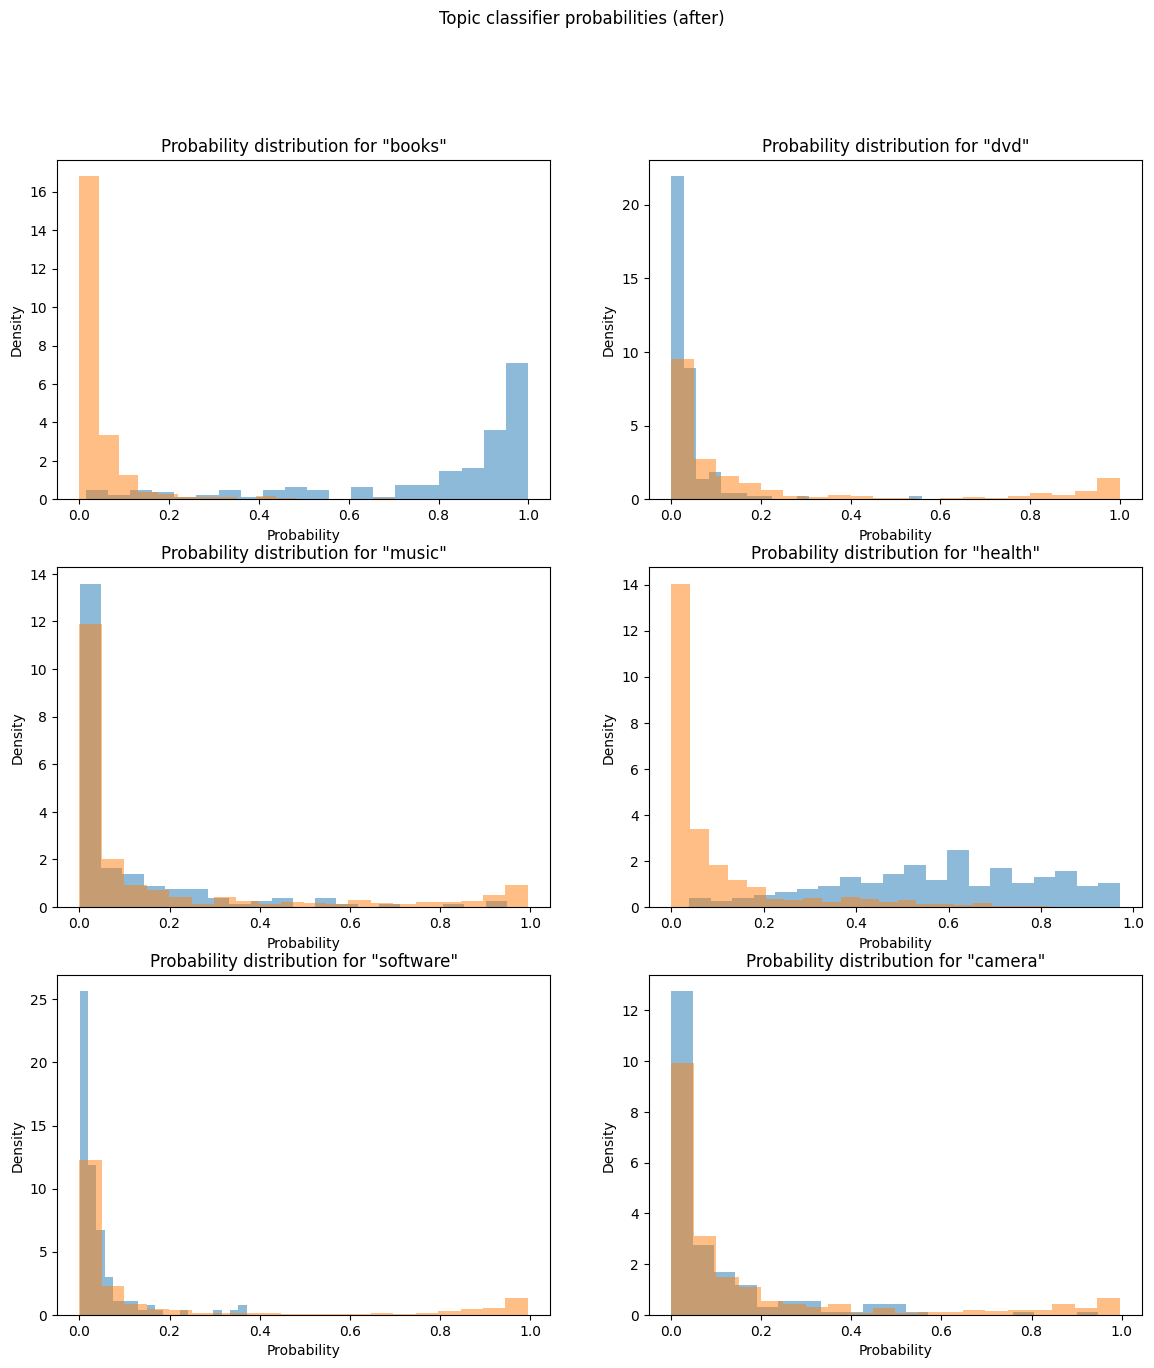

In [156]:
X = np.load("embedding_dist.npy")
Y = np.load("labels.npy", allow_pickle=True)[:, 0]

X_tr, X_te, Y_tr, Y_te = train_test_split(X, Y, test_size=0.2)

logreg = LogisticRegression()
logreg.fit(X_tr, Y_tr)
preds = logreg.predict_proba(X_te)

plot_topic_hists(preds, Y_te, "Topic classifier probabilities (after)")
plt.savefig("topic_after.png")
plt.show()